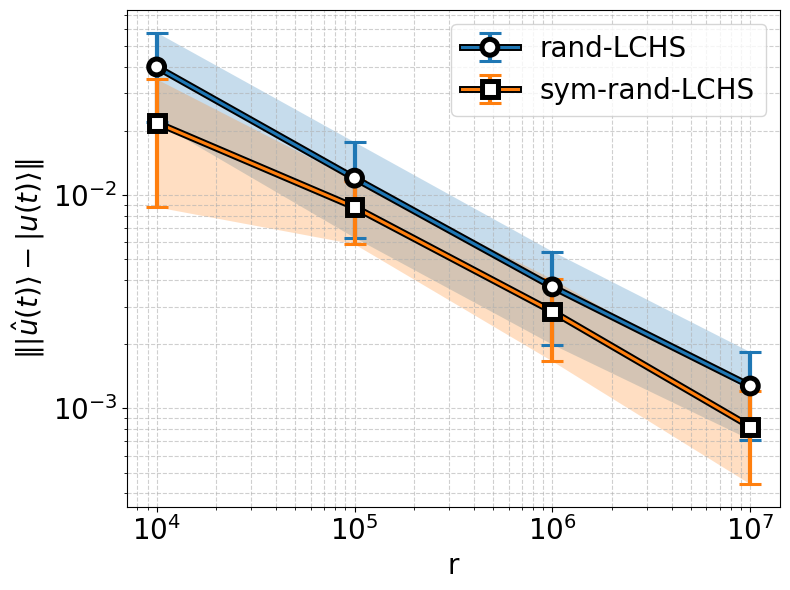

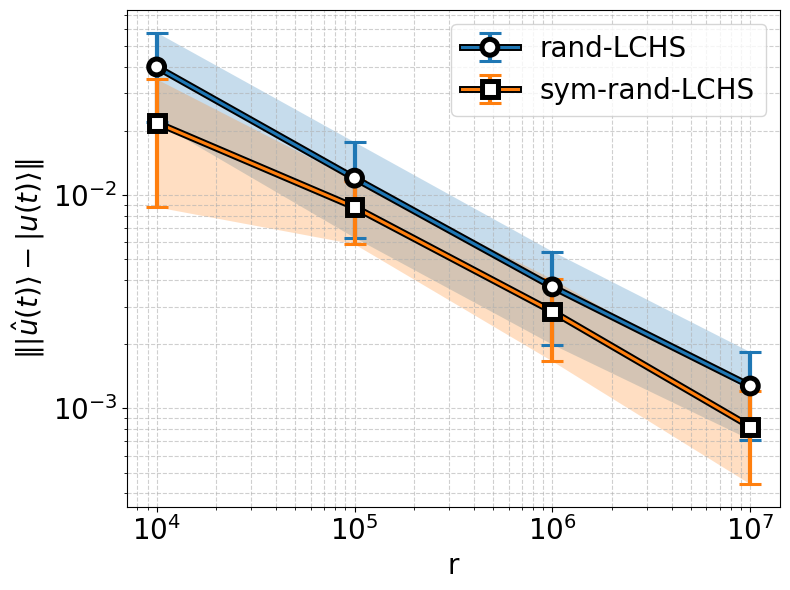

In [5]:
"""
reproduce_plots.py
Load saved data and reproduce the exact plots
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# ========== PLOTTING SETTINGS (copy from original) ==========
alpha_band = 0.25
capsize_val = 8
elinewidth_val = 3
marker_size = 10
marker_edge_width = 2.2

def cartoon_errorplot(x, y_mean, y_std, label, marker='o'):
    """Exact same function from original code"""
    lower = y_mean - y_std
    upper = y_mean + y_std
    plt.fill_between(x, lower, upper, alpha=alpha_band, linewidth=0)

    eb = plt.errorbar(x, y_mean, yerr=y_std,
                      marker=marker, markersize=marker_size,
                      markeredgecolor='black', markeredgewidth=marker_edge_width,
                      markerfacecolor='white',
                      elinewidth=elinewidth_val, capsize=capsize_val, capthick=elinewidth_val,
                      linestyle='-', linewidth=2.2, label=label)

    line = eb[0]
    line.set_path_effects([pe.Stroke(linewidth=5, foreground='black'), pe.Normal()])

    try:
        caps = eb[1]
        for c in caps:
            c.set_linewidth(elinewidth_val)
    except Exception:
        pass
    try:
        bars = eb[2]
        for b in bars:
            try:
                b.set_linewidth(elinewidth_val)
            except Exception:
                pass
    except Exception:
        pass

    return eb

# ========== REPRODUCE PLOTS ==========
# Load TFIM data
tfim_data = np.load('tfim_plot_data.npz')
Ms_arr = tfim_data['Ms_arr']
q_mean_n = tfim_data['q_mean_n']
q_std_n = tfim_data['q_std_n']
s_mean_n = tfim_data['s_mean_n']
s_std_n = tfim_data['s_std_n']

# Reproduce TFIM plot
plt.figure(figsize=(8, 6))
cartoon_errorplot(Ms_arr, q_mean_n, q_std_n, label='rand-LCHS', marker='o')
cartoon_errorplot(Ms_arr, s_mean_n, s_std_n, label='sym-rand-LCHS', marker='s')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('r', fontsize=20)
plt.ylabel(r'$\| |\hat{u}(t)\rangle-|u(t)\rangle \|$', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

leg = plt.legend(frameon=True, fontsize=13)
leg.get_frame().set_linewidth(1.6)
leg.get_frame().set_edgecolor('black')
plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.6)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

# Load HN data
hn_data = np.load('hn_plot_data.npz')
Ms_arr = hn_data['Ms_arr']
q_mean_n = hn_data['q_mean_n']
q_std_n = hn_data['q_std_n']
s_mean_n = hn_data['s_mean_n']
s_std_n = hn_data['s_std_n']

# Reproduce HN plot
plt.figure(figsize=(8, 6))
cartoon_errorplot(Ms_arr, q_mean_n, q_std_n, label='rand-LCHS', marker='o')
cartoon_errorplot(Ms_arr, s_mean_n, s_std_n, label='sym-rand-LCHS', marker='s')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('r', fontsize=20)
plt.ylabel(r'$\| |\hat{u}(t)\rangle-|u(t)\rangle \|$', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

leg = plt.legend(frameon=True, fontsize=13)
leg.get_frame().set_linewidth(1.6)
leg.get_frame().set_edgecolor('black')
plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.6)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

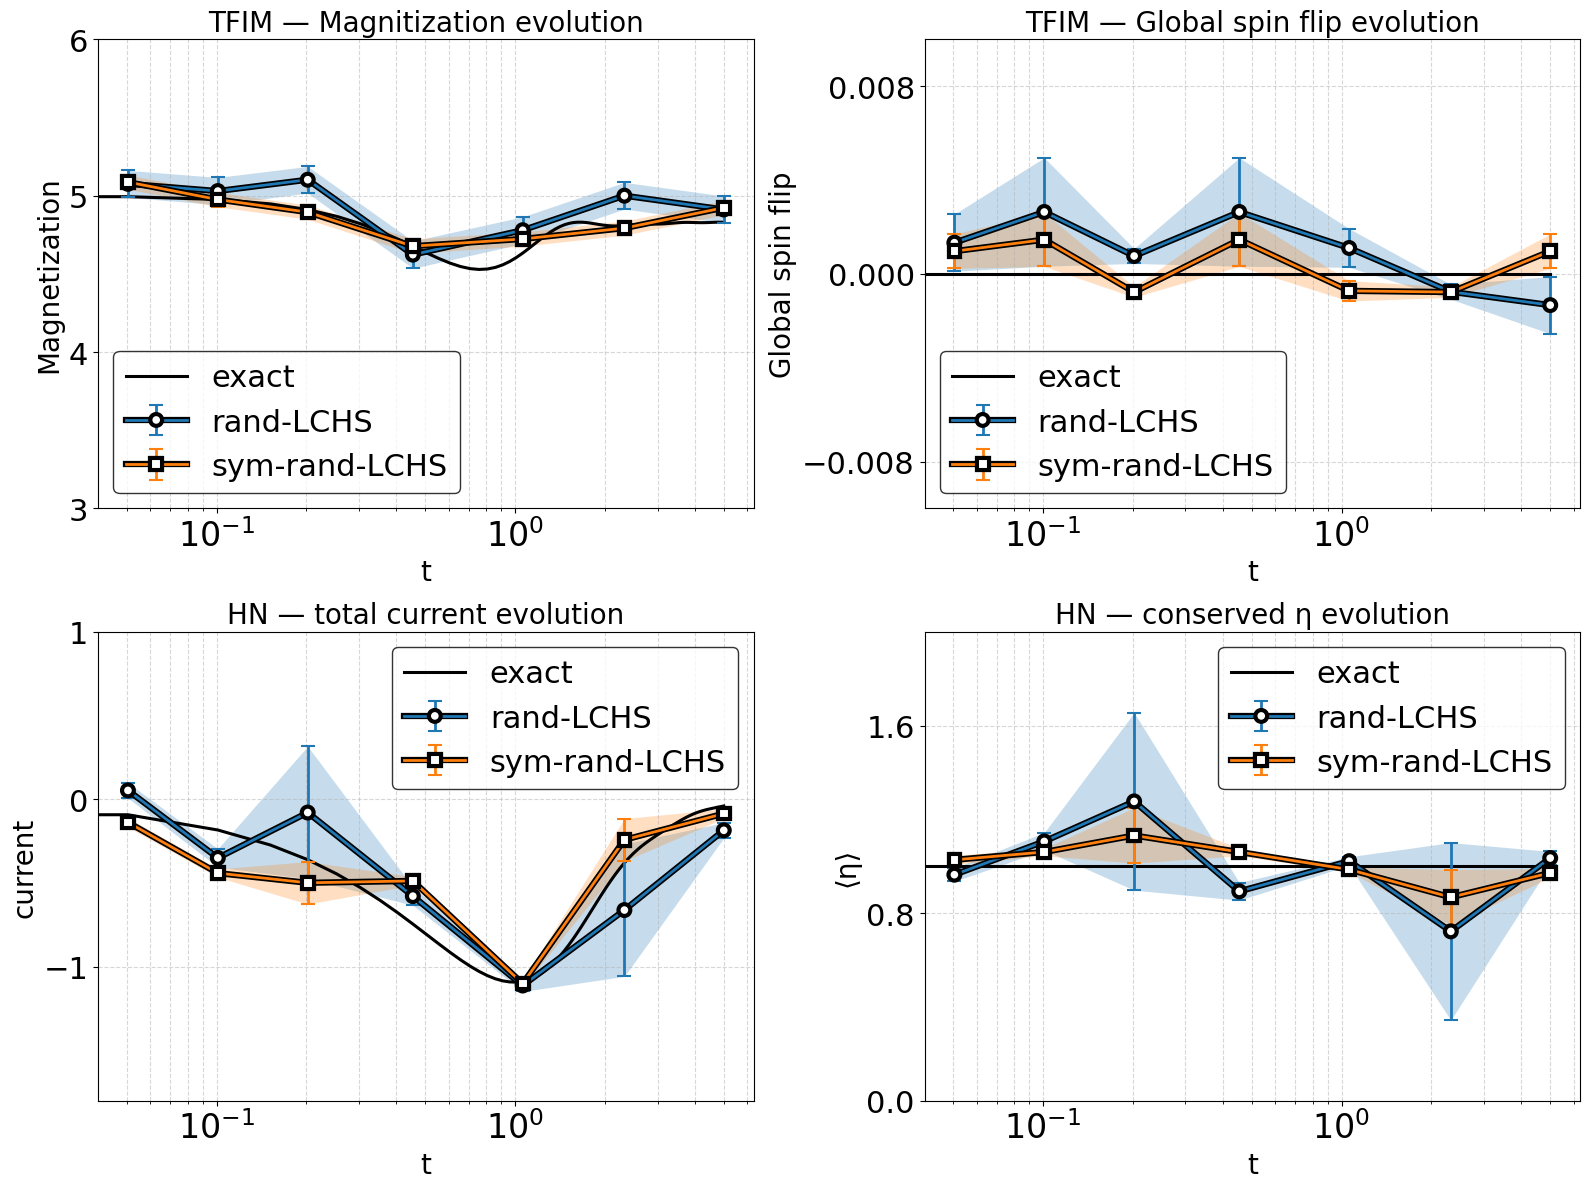

In [1]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import LogFormatter, MaxNLocator

alpha_band = 0.25
marker_size = 7
marker_edge_width = 1.5
elinewidth_val = 2.0
capsize_val = 5

with open('fig3_data.pkl', 'rb') as f:
    data = pickle.load(f)

t_points = data['t_points']
exact = data['exact_data']
pred = data['pred_data']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

def reproduce_plot(ax, times, exact_arr, pred1, label1, color1, pred2, label2, color2, title, ylabel, ylim=None):
    ax.plot(times, exact_arr, '-', lw=2.2, label='exact', color='black', zorder=5)
    if pred1['sparse_indices'] is not None:
        mt = times[pred1['sparse_indices']]
        ax.fill_between(mt, pred1['predicted']-pred1['std'], pred1['predicted']+pred1['std'], alpha=alpha_band, linewidth=0, color=color1)
        eb = ax.errorbar(mt, pred1['predicted'], yerr=pred1['std'], marker='o', markersize=marker_size, markeredgecolor='black', markeredgewidth=marker_edge_width, markerfacecolor='white', elinewidth=elinewidth_val, capsize=capsize_val, capthick=elinewidth_val, linestyle='-', linewidth=2.0, label=label1, color=color1, zorder=6)
        eb[0].set_path_effects([pe.Stroke(linewidth=4.5, foreground='black'), pe.Normal()])
    if pred2['sparse_indices'] is not None:
        mt = times[pred2['sparse_indices']]
        ax.fill_between(mt, pred2['predicted']-pred2['std'], pred2['predicted']+pred2['std'], alpha=alpha_band, linewidth=0, color=color2)
        eb = ax.errorbar(mt, pred2['predicted'], yerr=pred2['std'], marker='s', markersize=marker_size, markeredgecolor='black', markeredgewidth=marker_edge_width, markerfacecolor='white', elinewidth=elinewidth_val, capsize=capsize_val, capthick=elinewidth_val, linestyle='-', linewidth=2.0, label=label2, color=color2, zorder=6)
        eb[0].set_path_effects([pe.Stroke(linewidth=4.5, foreground='black'), pe.Normal()])
    ax.tick_params(axis='y', which='major', labelsize=22)
    ax.xaxis.set_major_formatter(LogFormatter(labelOnlyBase=False))
    ax.tick_params(axis='x', which='major', labelsize=24)
    ax.yaxis.set_major_locator(MaxNLocator(3))
    if ylim: ax.set_ylim(ylim)
    ax.set_xscale('log')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.set_xlabel('t', fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.set_title(title, fontsize=20)
    ax.legend(fontsize=22, edgecolor='black', facecolor='white')

reproduce_plot(axes[0,0], t_points, exact['tfim_exact_N'], pred['tfim_particle_rand'], 'rand-LCHS', '#1f77b4', pred['tfim_particle_symrand'], 'sym-rand-LCHS', '#ff7f0e', 'TFIM — Magnitization evolution', 'Magnetization', (3,6))
reproduce_plot(axes[0,1], t_points, exact['tfim_exact_G'], pred['tfim_globalX_rand'], 'rand-LCHS', '#1f77b4', pred['tfim_globalX_symrand'], 'sym-rand-LCHS', '#ff7f0e', 'TFIM — Global spin flip evolution', 'Global spin flip', (-0.01,0.01))
reproduce_plot(axes[1,0], t_points, exact['hn_exact_curr'], pred['hn_current_rand'], 'rand-LCHS', '#1f77b4', pred['hn_current_symrand'], 'sym-rand-LCHS', '#ff7f0e', 'HN — total current evolution', 'current', (-1.8,1))
reproduce_plot(axes[1,1], t_points, exact['hn_exact_eta'], pred['hn_eta_rand'], 'rand-LCHS', '#1f77b4', pred['hn_eta_symrand'], 'sym-rand-LCHS', '#ff7f0e', 'HN — conserved η evolution', '⟨η⟩', (0.0,2))

plt.tight_layout()
plt.show()